In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("MERGE_SAHAM_GABUNGAN_FINAL (1).csv")

# Parsing tanggal
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)

df.head()


,Unnamed: 0,tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,avg_sentiment,prop_pos,prop_neg,prop_neu,count,max_impact
0,0,2022-01-03,6665.31,6586.26,6677.20,6586.13,1.826000e+10,1.27,0.000000,0.0,0.0,1.0,1.0,netral
1,1,2022-01-04,6695.37,6675.13,6720.66,6675.13,1.859000e+10,0.45,0.789194,1.0,0.0,0.0,2.0,positif
2,2,2022-01-05,6662.30,6703.17,6738.11,6634.84,1.791000e+10,-0.49,0.000000,0.0,0.0,1.0,0.0,netral
3,3,2022-01-06,6653.35,6674.85,6679.85,6593.23,1.800000e+10,-0.13,-0.646163,0.0,1.0,0.0,1.0,negatif
4,4,2022-01-07,6701.32,6669.51,6712.15,6647.71,1.571000e+10,0.72,0.500000,0.5,0.0,0.5,2.0,positif


In [2]:
impact_map = {
    'negatif': -1,
    'netral': 0,
    'positif': 1
}

df['max_impact'] = df['max_impact'].str.lower().map(impact_map)

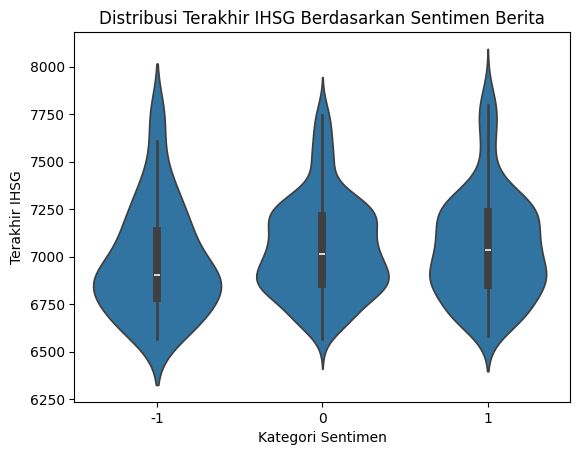

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df[['max_impact', 'Terakhir']].dropna()

plt.figure()
sns.violinplot(x='max_impact', y='Terakhir', data=df_plot)
plt.title('Distribusi Terakhir IHSG Berdasarkan Sentimen Berita')
plt.xlabel('Kategori Sentimen')
plt.ylabel('Terakhir IHSG')
plt.show()

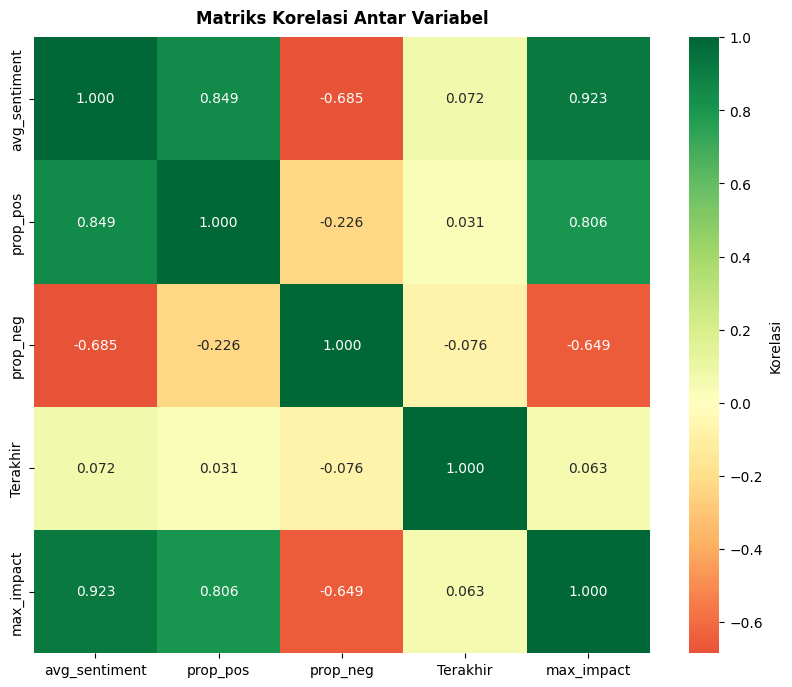

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax5 = plt.subplots(figsize=(10, 8))

corr_vars = [
    'avg_sentiment',
    'prop_pos',
    'prop_neg',
    'Terakhir', # Changed from 'Return_IHSG'
    'max_impact', # Changed from 'max_impact_numeric'
]

corr_matrix = df[corr_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, ax=ax5, cbar_kws={'label': 'Korelasi'})
ax5.set_title('Matriks Korelasi Antar Variabel', fontweight='bold', pad=10)
plt.show()

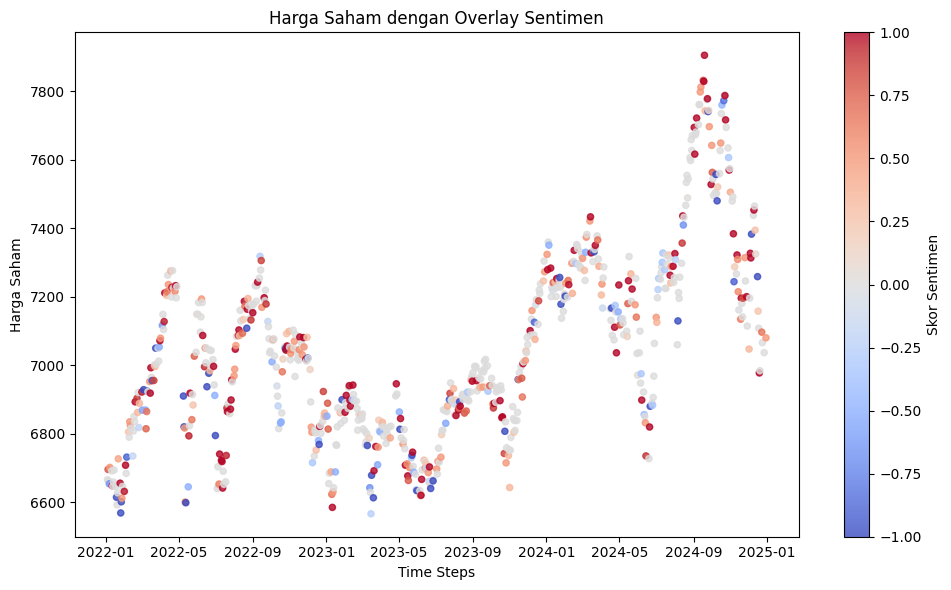

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df = df.sort_values('tanggal').reset_index(drop=True)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['tanggal'],        # atau df['tanggal']
    df['Terakhir'],
    c=df['avg_sentiment'],   # overlay sentimen
    cmap='coolwarm',
    alpha=0.8,
    s=20
)

plt.colorbar(scatter, label='Skor Sentimen')
plt.title('Harga Saham dengan Overlay Sentimen')
plt.xlabel('Time Steps')
plt.ylabel('Harga Saham')

plt.tight_layout()
plt.show()